In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
from xgboost.sklearn import XGBRegressor
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
import xgboost as xgb
from xgboost.callback import EarlyStopping
from sklearn.model_selection import GridSearchCV, KFold
import seaborn as sns

In [13]:
train_x = pd.read_csv("train_X.csv")
train_y = pd.read_csv("train_y.csv")

test_x = pd.read_csv("test_X.csv")
test_y = pd.read_csv("test_y.csv")

In [16]:
train_x = train_x.drop(columns=['Id', 'Material'])
test_x = test_x.drop(columns=['Id', 'Material'])
train_y = train_y.drop(columns=['Id'])
train_y = np.log1p(train_y)
test_y = test_y.drop(columns=['Id'])
test_y = np.log1p(test_y)

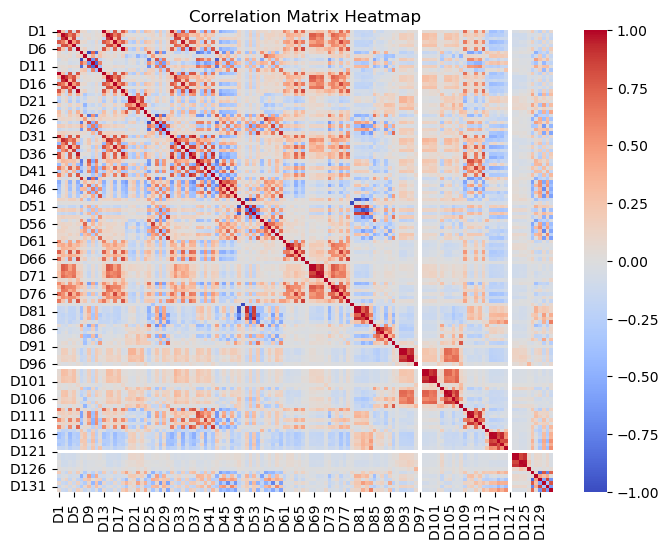

In [20]:
m = train_x.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(m, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

In [22]:
train_x = train_x.drop(columns=['D97', 'D121'])
test_x = test_x.drop(columns=['D97', 'D121'])

In [24]:
train_y

,Egap
0,1.338180
1,1.256413
2,1.082144
3,0.698085
4,1.369758
...,...
9635,0.997096
9636,0.711724
9637,0.944684
9638,0.296394


In [20]:
xgb_model = xgb.XGBRegressor(
    objective="reg:absoluteerror",
    tree_method="hist",
    random_state=42,
    early_stopping_rounds=50
)

param_grid = {
    "n_estimators": [300, 500, 700],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 4, 5],
    "subsample": [0.6, 0.7, 0.8, 0.9],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9],
    "reg_lambda": [1, 2, 3],
    "reg_alpha": [0, 0.5]
}

kf = KFold(n_splits=3, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=kf,
    n_jobs=-1,
    verbose=2
)


fit_params = {
    "eval_set": [(train_x.iloc[:200], train_y.iloc[:200])],  
}

grid.fit(train_x, train_y, **fit_params)

print("Best params:", grid.best_params_)
print("Best CV MAE:", -grid.best_score_)


Fitting 3 folds for each of 3456 candidates, totalling 10368 fits
[0]	validation_0-mae:0.39228
[1]	validation_0-mae:0.37311
[2]	validation_0-mae:0.35626
[3]	validation_0-mae:0.34094
[4]	validation_0-mae:0.32746
[5]	validation_0-mae:0.31716
[6]	validation_0-mae:0.30778
[7]	validation_0-mae:0.29914
[8]	validation_0-mae:0.29184
[9]	validation_0-mae:0.28441
[10]	validation_0-mae:0.27990
[11]	validation_0-mae:0.27435
[12]	validation_0-mae:0.26990
[13]	validation_0-mae:0.26486
[14]	validation_0-mae:0.26087
[15]	validation_0-mae:0.25669
[16]	validation_0-mae:0.25427
[17]	validation_0-mae:0.25126
[18]	validation_0-mae:0.24908
[19]	validation_0-mae:0.24710
[20]	validation_0-mae:0.24545
[21]	validation_0-mae:0.24329
[22]	validation_0-mae:0.24115
[23]	validation_0-mae:0.23929
[24]	validation_0-mae:0.23781
[25]	validation_0-mae:0.23665
[26]	validation_0-mae:0.23581
[27]	validation_0-mae:0.23448
[28]	validation_0-mae:0.23355
[29]	validation_0-mae:0.23211
[30]	validation_0-mae:0.23193
[31]	validatio

In [22]:
best_model = grid.best_estimator_
test_preds = best_model.predict(test_x)

test_mae = mean_absolute_error(test_y, test_preds)
print("\nTEST MAE:", test_mae)


test_X_full = pd.read_csv("test_X.csv")
submission = pd.DataFrame({
    "Id": test_X_full["Id"],
    "Egap": test_preds
})
submission.to_csv("submission_grid_earlystopping.csv", index=False)

print("Saved submission_grid_earlystopping.csv")


TEST MAE: 0.5134649872779846
Saved submission_grid_earlystopping.csv


In [15]:
import xgboost as xgb
from sklearn.model_selection import KFold, GridSearchCV

xgb_base = xgb.XGBRegressor(
    objective="reg:absoluteerror",
    tree_method="hist",
    random_state=42
)

param_grid = {
    "n_estimators": [300, 500],
    "learning_rate": [0.03, 0.1],
    "max_depth": [3, 4],
    "subsample": [0.7, 0.9],
    "colsample_bytree": [0.7, 0.9],
}

kf = KFold(n_splits=3, shuffle=True, random_state=42)

class EarlyStopper:
    """Custom wrapper so each CV fold gets its own eval_set."""
    def __init__(self, X, y, kf):
        self.X = X
        self.y = y
        self.kf = list(kf.split(X))

    def get_params(self, deep=False):
        return {}

    def set_params(self, **params):
        return self

    def fit(self, X, y):
        pass

def fit_with_es(estimator, X, y):
    est = estimator
    es = xgb.callback.EarlyStopping(rounds=40, save_best=True)

    est.fit(
        X_train_fold,
        y_train_fold,
        eval_set=[(X_valid_fold, y_valid_fold)],
        callbacks=[es],
        verbose=False
    )
    return est

# Custom CV with early stopping
def cv_with_es(estimator, X, y):
    models = []
    scores = []

    for train_idx, valid_idx in kf.split(X):
        X_train_fold = X.iloc[train_idx]
        y_train_fold = y.iloc[train_idx]
        X_valid_fold = X.iloc[valid_idx]
        y_valid_fold = y.iloc[valid_idx]

        model = estimator.__class__(**estimator.get_params())
        es = xgb.callback.EarlyStopping(rounds=40, save_best=True)

        model.fit(
            X_train_fold,
            y_train_fold,
            eval_set=[(X_valid_fold, y_valid_fold)],
            callbacks=[es],
            verbose=False
        )

        pred = model.predict(X_valid_fold)
        fold_mae = abs(pred - y_valid_fold).mean()

        scores.append(fold_mae)
        models.append(model)

    return sum(scores)/len(scores)

grid = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=kf,
    n_jobs=-1
)

grid.fit(train_x, train_y)

print("BEST PARAMS:", grid.best_params_)
print("BEST CV MAE:", -grid.best_score_)

best_model = grid.best_estimator_
test_preds = best_model.predict(test_x)

test_mae = mean_absolute_error(test_y, test_preds)
print("\nTEST MAE:", test_mae)

# ------------------------------------
# Save submission CSV
# ------------------------------------
test_X_full = pd.read_csv("test_X.csv")
submission = pd.DataFrame({
    "Id": test_X_full["Id"],
    "Egap": test_preds
})
submission.to_csv("submission_grid_earlystopping.csv", index=False)

print("Saved submission_grid_earlystopping.csv")


KeyboardInterrupt



In [24]:
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
import numpy as np

kf = KFold(n_splits=10, shuffle=True, random_state=42)

oof = np.zeros(len(train_x))
test_preds = np.zeros(len(test_x))

for fold, (train_idx, valid_idx) in enumerate(kf.split(train_x)):
    print(f"\n==== Fold {fold+1} ====")
    
    X_tr, X_val = train_x.iloc[train_idx], train_x.iloc[valid_idx]
    y_tr, y_val = train_y.iloc[train_idx], train_y.iloc[valid_idx]

    model = CatBoostRegressor(
        iterations=3000,
        learning_rate=0.02,
        depth=6,
        loss_function="MAE",
        eval_metric="MAE",
        random_seed=42,
        verbose=False,
        od_type="Iter",
        od_wait=100
    )

    model.fit(X_tr, y_tr, eval_set=(X_val, y_val), verbose=False)

    oof[valid_idx] = model.predict(X_val)
    test_preds += model.predict(test_x) / kf.n_splits

cv_mae = mean_absolute_error(train_y, oof)
print("\nCV MAE:", cv_mae)

test_mae = mean_absolute_error(test_y, test_preds)
print("TEST MAE:", test_mae)



==== Fold 1 ====

==== Fold 2 ====

==== Fold 3 ====

==== Fold 4 ====

==== Fold 5 ====

==== Fold 6 ====

==== Fold 7 ====

==== Fold 8 ====

==== Fold 9 ====

==== Fold 10 ====

CV MAE: 0.17820518140269498
TEST MAE: 0.5120087721150959


In [26]:
test_X_full = pd.read_csv("test_X.csv")
submission = pd.DataFrame({
    "Id": test_X_full["Id"],
    "Egap": test_preds
})
submission.to_csv("submission_grid_earlystopping.csv", index=False)

print("Saved submission_catboost.csv")

Saved submission_catboost.csv


## write-up

For this assignment,we are supposed to predict the band gap of certain materials based on various characteristics they posess. To accomplish this regression problem, I decided to test out an XGBRegressor model and a CatBoosRegressor model. I chose these models because XGB adds regularization to the trees to mitigate the noise and Cat is great at handling mixed data types and utilizes ordered boosting to reduce leakage and prediction bias. First I dropped Id' and the 'Material' columns to run a correlation matrix. From the matrix, I noticed that columns 'D97' and 'D121' were all 0 so I dropped those columns. I also applied a log on the target values so the distributions are the same. Using the remaining columns, I trained both models, compared, and utilized grid search to find the best hyperparametrs. Both models did rougly the same in regards to the resulting MAE of the test data, with Cat outperforming by almost 0.001. However, they may be some overfitting present in both models as the cross validation MAE is much lower than the test  MAE, but both are lett that 1. What this means is further tuning of the hyperparameters must be done to mitigate the minor over fitting.